**K.V.Kozenko, V.V.Gromyko, I.I.Beterov, I.I.Ryabtsev. Pulse profiles for amplitude-robust gates. We use Rydopt package David F. Locher, Josias Old, Katharina Brechtelsbauer, Jakob Holschbach, Hans Peter Büchler, Sebastian Weber, Markus Müller, Multiqubit Rydberg Gates for Quantum Error Correction, arXiv:2512.00843**

In [1]:
import rydopt as ro
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from rydopt.types import HamiltonianFunction
import jax
import copy 
from jax.scipy.special import factorial

C:\Users\Ilya Beterov\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Pulse plot with saving to file**

In [2]:
from typing import cast
from rydopt.pulses.pulse_ansatz import PulseAnsatz
from rydopt.types import PulseParams
def plot_pulse(
    pulse: PulseAnsatz,
    params: PulseParams,
    *,
    plot_detuning: bool = True,
    plot_phase: bool = True,
    plot_rabi: bool = True,
    subtract_phase_offset: bool = False,
    num_points: int = 1024,
    ax: plt.Axes | None = None,
) -> tuple[plt.Figure, plt.Axes]:
    
    duration = params[0]

    times = jnp.linspace(0, duration, num_points)

    # Evaluated pulse
    selector = [plot_detuning, plot_phase, plot_rabi]

    values = np.array(pulse.evaluate_pulse_functions(times, params))
    if subtract_phase_offset:
        values[1] -= values[1][0]
    values = values[selector]

    labels = np.array(
        [
            r"$\Delta(t)$",
            r"$\xi(t)$",
            r"$\Omega(t)$",
        ]
    )[selector]

    ylabel = ", ".join(
        np.array(
            [
                r"$T\Delta $",
                r"$\xi$ [rad]",
                r"$T\Omega $",
            ]
        )[selector]
    )

    # Plot pulse
    owns_ax = ax is None

    if owns_ax:
        fig, ax = plt.subplots(figsize=(4, 3))
    else:
        assert ax is not None
        fig = cast(plt.Figure, ax.figure)

    for v, label in zip(values, labels):
        ax.plot(times, v, label=label)

    if owns_ax:
        ax.set_xmargin(0)
        ax.set_xlabel(r"$t/ T$")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        ax.legend()
        fig.tight_layout()
    plt.savefig('Pulse_plot.svg', format='svg')
    return fig, ax

**Smooth gate defined by Bernstein basis**

In [3]:
def C(n, k):
    return factorial(n) / (factorial(k) * factorial(n - k))
def B(n, k, x):
    return C(n, k) * (x ** k) * ((1 - x) ** (n - k))
def Bernstein(t, duration, params):
    n = 8
    x = t / duration
    result = 0.0
    for i in range(4):
        p = params[i]
        result += p * (B(n, i + 1, x) + B(n, n - i - 1, x))
    return result

In [4]:
s_standart_metrics_params = (19.056509827597598, [-0.85065763], [-0.70256077, 0.52556574, -0.6018667, 0.42860556, -0.1344891, -0.29475093, -0.861658, 0.94411749, -0.2533745, 0.32880198, -0.30333004, 0.20995299, -0.94282043, 0.13511527, 0.28957941, 0.28834211, 0.67177751], [1.55637022, 0.55076984, 0.70632529, 0.74342892])
s_best_new_metrics_params = (15.579234051422459, [-0.10306642], [0.25713014, -0.0371261, -0.39030259, -0.67057359, -0.41130002, -1.1371409, 0.06083949, 0.48378767, 0.37380998, -0.44239411, -0.16195767, -0.14500935, 0.72270159, 0.16039615, 0.3688463, 0.11764288, -0.16464327], [0.73668924, 1.08468747, 0.88225812, 0.9818675])
s_first_new_metrics_params = (15.975069568227315, [0.19328834], [0.31073727, 0.19638632, 0.40065998, 0.9822026, 1.01008757, -0.44587052, 0.62394907, -0.04853542, 0.9387376, -0.31069435, -0.14696333, 0.61255958, -0.28107441, 0.84381843, -0.24455851, 0.23182069, -0.51628684], [0.71003108, 1.4797429, 0.99818094, 0.93491192])
s_end_new_metrics_params = (13.595904652315461, [0.53805468], [-0.31105438, -0.26510089, -0.1920439, 0.61494857, -0.03246178, 0.2204744, -0.46698452, -0.41345293, 0.03208933, -0.09979141, -0.56643729, -0.06769074, 0.00469906, 0.67592464, 0.5015271, 0.42757434, 0.01183594], [1.5006904, 0.99464455, 0.98381808, 1.27084941])

In [5]:
jax.config.update("jax_enable_x64", True)
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
pulse_ansatz_s = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.lin_sin_cos_crab,
    rabi_ansatz=Bernstein)

s_jax_standart_metrics_params = (jnp.array(s_standart_metrics_params[0]), 
                                jnp.array(s_standart_metrics_params[1]), 
                                jnp.array(s_standart_metrics_params[2]), 
                                jnp.array(s_standart_metrics_params[3]))

s_jax_best_new_metrics_params = (jnp.array(s_best_new_metrics_params[0]), 
                                jnp.array(s_best_new_metrics_params[1]), 
                                jnp.array(s_best_new_metrics_params[2]), 
                                jnp.array(s_best_new_metrics_params[3]))

s_jax_first_new_metrics_params = (jnp.array(s_first_new_metrics_params[0]), 
                                jnp.array(s_first_new_metrics_params[1]), 
                                jnp.array(s_first_new_metrics_params[2]), 
                                jnp.array(s_first_new_metrics_params[3]))

s_jax_end_new_metrics_params = (jnp.array(s_end_new_metrics_params[0]), 
                                jnp.array(s_end_new_metrics_params[1]), 
                                jnp.array(s_end_new_metrics_params[2]), 
                                jnp.array(s_end_new_metrics_params[3]))

def scale_params(params, eps):
    duration = params[0]
    detuning_p = params[1]
    phase_p = params[2]
    rabi_p = params[3] 
    rabi_p_noisy = rabi_p * (1 + eps)
    return (duration, detuning_p, phase_p, rabi_p_noisy)

def compute_fidelity_single(eps, base_params):
    noisy_p = scale_params(base_params, eps)
    
    final_state = ro.simulation.evolve(gate, pulse_ansatz_s, noisy_p)
    return gate.process_fidelity(final_state)

compute_fidelity_vmap = jax.vmap(compute_fidelity_single, in_axes=(0, None))
compute_fidelity_jit = jax.jit(compute_fidelity_vmap)

Eps = jnp.linspace(-0.05, 0.05, 21)
F_s_standart_metrics_params = compute_fidelity_jit(Eps, s_jax_standart_metrics_params)
F_s_best_new_metrics_params = compute_fidelity_jit(Eps, s_jax_best_new_metrics_params)
F_s_first_new_metrics_params = compute_fidelity_jit(Eps, s_jax_first_new_metrics_params)
F_s_end_new_metrics_params= compute_fidelity_jit(Eps, s_jax_end_new_metrics_params)

inf_s_standart_metrics_params = np.abs(1 - np.array(F_s_standart_metrics_params))
inf_s_best_new_metrics_params = 1 - np.array(F_s_best_new_metrics_params)
inf_s_first_new_metrics_params = 1 - np.array(F_s_first_new_metrics_params)
inf_s_end_new_metrics_params = 1 - np.array(F_s_end_new_metrics_params)

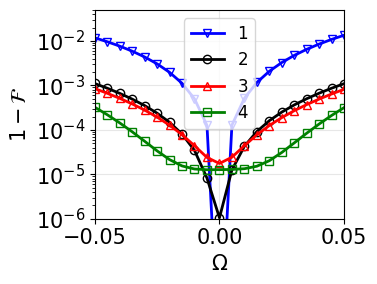

In [6]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
ax.plot(Eps, inf_s_standart_metrics_params, label='1', color='blue', markersize=6,marker='v',mfc='none' )
ax.plot(Eps, inf_s_best_new_metrics_params, label='2', color='black',marker='o', mfc='none',markersize=6)
ax.plot(Eps, inf_s_first_new_metrics_params,  label='3', color='red',marker='^', mfc='none', markersize=6)
ax.plot(Eps, inf_s_end_new_metrics_params, label='4', color='green', markersize=6, marker='s', mfc='none',)
# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\Omega$", fontsize=15, fontweight='bold')
ax.set_ylabel(r"$1-\mathcal{F}$", fontsize=15, fontweight='bold')
ax.set_yscale('log')
ax.tick_params(axis='both', labelsize=15,)
ax.set_xlim(-0.05, 0.05)
ax.set_ylim(1e-6,5e-2)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('Robustness_plot_Bernstein.svg', format='svg')
# Display the plot
plt.show()

In [9]:
end_new_metrics_params = (1, [0.53805468*13.595904652315461], [-0.31105438*13.595904652315461, -0.26510089, -0.1920439, 0.61494857, -0.03246178, 0.2204744, -0.46698452, -0.41345293, 0.03208933, -0.09979141, -0.56643729, -0.06769074, 0.00469906, 0.67592464, 0.5015271, 0.42757434, 0.01183594], [1.5006904*13.595904652315461, 0.99464455*13.595904652315461, 0.98381808*13.595904652315461, 1.27084941*13.595904652315461])

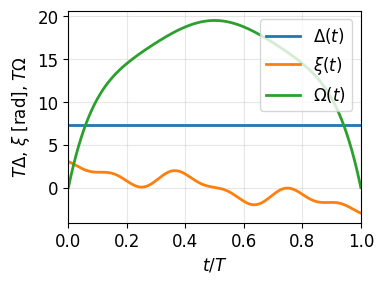

In [10]:
plot_pulse(pulse_ansatz_s, end_new_metrics_params);

**Smooth pulse shape**

In [11]:
to_standart_metrics_params = (24.861008287557933, [-0.01710893], [-0.68830701, 0.41704332, -0.38814211, -0.64009429, 0.17904722, 0.12231047, -0.15584452, -0.13319923, 0.20702963, -0.13333088, 0.45137939, 0.02220497, 0.20951565, 0.53210919, -0.37250782, -0.33195384, -0.03842618], [0.79094817, 0.58017336])
to_first_new_metrics_params = (22.68570202294605, [0.39359422], [0.00885486, 0.68899341, -1.30080717, 0.20565407, 1.52938521, -0.07793277, 0.01757168, 0.04656591, -0.23057974, -0.22372866, 0.33995966, -0.02251479, -0.61334726, 0.75851306, 0.04118993, -0.3609116, -0.57293211, -0.06627675, 0.43749798, -0.22426634, -0.5726781], [1.11164818, 0.31219758])
to_end_new_metrics_params = (22.662134135960255, [0.40433569], [0.01959632, 0.80582318, -1.29913162, 0.24595796, 1.75011831, 0.06425968, -0.15430385, 0.10287453, -0.18786168, -0.1484231, 0.2266793, -0.02549104, -0.6134942, 0.8116914, 0.10364234, -0.34698707, -0.57748581, -0.11806264, 0.50882035, -0.2240126, -0.58173406], [0.99964949+0.01, 0.25690718])
to_best_new_metrics_params =  (22.6868862158617, [0.39224932], [ 0.0075099,   0.68199632, -1.27315726,  0.16506267,  1.49066027, -0.10798176,
  0.04424316,  0.05026478, -0.29664049, -0.21997667,  0.31360116, -0.03479104,
 -0.63334245,  0.78054825,  0.050249,   -0.36991845, -0.58548868, -0.0607182,
  0.43260683, -0.23636854, -0.57772627], [1.11546456, 0.32053077])
to_final_new_metrics_params = (1.0, [9.161340713500977], [0.4423346519470215, 0.8069138526916504, -1.2970787286758423, 0.24585136771202087, 1.747451901435852, 0.06547801941633224, -0.14693093299865723, 0.10161710530519485, -0.18819914758205414, -0.14740043878555298, 0.22830304503440857, -0.025524446740746498, -0.6128880381584167, 0.8218499422073364, 0.10687456279993057, -0.3464415967464447, -0.5772057175636292, -0.11884554475545883, 0.5073965787887573, -0.2231883704662323, -0.5818129181861877], [22.71428108215332, 0.25830256938934326])

#to_first_new_metrics_params

In [12]:
jax.config.update("jax_enable_x64", True)
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)

pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)

to_jax_standart_metrics_params = (jnp.array(to_standart_metrics_params[0]), 
                                jnp.array(to_standart_metrics_params[1]), 
                                jnp.array(to_standart_metrics_params[2]), 
                                jnp.array(to_standart_metrics_params[3]))

to_jax_best_new_metrics_params = (jnp.array(to_best_new_metrics_params[0]), 
                                jnp.array(to_best_new_metrics_params[1]), 
                                jnp.array(to_best_new_metrics_params[2]), 
                                jnp.array(to_best_new_metrics_params[3]))

to_jax_first_new_metrics_params = (jnp.array(to_first_new_metrics_params[0]), 
                                jnp.array(to_first_new_metrics_params[1]), 
                                jnp.array(to_first_new_metrics_params[2]), 
                                jnp.array(to_first_new_metrics_params[3]))

to_jax_end_new_metrics_params = (jnp.array(to_end_new_metrics_params[0]), 
                                jnp.array(to_end_new_metrics_params[1]), 
                                jnp.array(to_end_new_metrics_params[2]), 
                                jnp.array(to_end_new_metrics_params[3]))

to_jax_final_new_metrics_params = (jnp.array(to_final_new_metrics_params[0]), 
                                jnp.array(to_final_new_metrics_params[1]), 
                                jnp.array(to_final_new_metrics_params[2]), 
                                jnp.array(to_final_new_metrics_params[3]))


def scale_params(params, eps):
    duration = params[0]
    detuning_p = params[1]
    phase_p = params[2]
    rabi_p = params[3] 
    rabi_p_noisy = rabi_p.at[0].set(rabi_p[0] * (1 + eps))
    return (duration, detuning_p, phase_p, rabi_p_noisy)

def compute_fidelity_single(eps, base_params):
    noisy_p = scale_params(base_params, eps)
    final_state = ro.simulation.evolve(gate, pulse_ansatz_to, noisy_p)
    return gate.process_fidelity(final_state)

compute_fidelity_vmap = jax.vmap(compute_fidelity_single, in_axes=(0, None))
compute_fidelity_jit = jax.jit(compute_fidelity_vmap)

Eps = jnp.linspace(-0.05, 0.05, 31)
F_to_standart_metrics_params = compute_fidelity_jit(Eps, to_jax_standart_metrics_params)
F_to_best_new_metrics_params = compute_fidelity_jit(Eps, to_jax_best_new_metrics_params)
F_to_first_new_metrics_params = compute_fidelity_jit(Eps, to_jax_first_new_metrics_params)
F_to_end_new_metrics_params= compute_fidelity_jit(Eps, to_jax_end_new_metrics_params)
F_to_final_new_metrics_params= compute_fidelity_jit(Eps, to_jax_final_new_metrics_params)

inf_to_standart_metrics_params = 1 - np.array(F_to_standart_metrics_params)
inf_to_best_new_metrics_params = 1 - np.array(F_to_best_new_metrics_params)
inf_to_first_new_metrics_params = 1 - np.array(F_to_first_new_metrics_params)
inf_to_end_new_metrics_params = 1 - np.array(F_to_end_new_metrics_params)
inf_to_final_new_metrics_params = 1 - np.array(F_to_final_new_metrics_params)

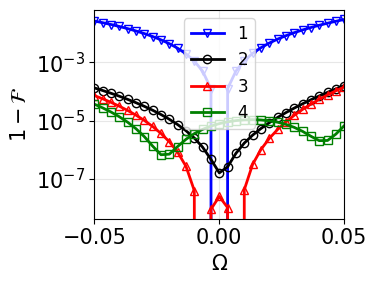

In [13]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
ax.plot(Eps, inf_to_standart_metrics_params, label='1', color='blue', markersize=6,marker='v',mfc='none' )
ax.plot(Eps, inf_to_best_new_metrics_params, label='2', color='black',marker='o', mfc='none',markersize=6)
ax.plot(Eps, inf_to_first_new_metrics_params,  label='3', color='red',marker='^', mfc='none', markersize=6)
ax.plot(Eps, inf_to_final_new_metrics_params, label='4', color='green', markersize=6, marker='s', mfc='none')
# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\Omega$", fontsize=15, fontweight='bold')
ax.set_ylabel(r"$1-\mathcal{F}$", fontsize=15, fontweight='bold')
ax.set_yscale('log')
ax.tick_params(axis='both', labelsize=15,)
ax.set_xlim(-0.05, 0.05)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('Robustness_to_plot.svg', format='svg')
# Display the plot
plt.show()

(<Figure size 400x300 with 1 Axes>,
 <Axes: xlabel='$t/ T$', ylabel='$T\\Delta $, $\\xi$ [rad], $T\\Omega $'>)

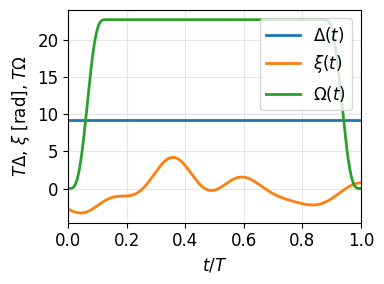

In [15]:
to_final_new_metrics_params = (1.0, [9.161340713500977], [0.4423346519470215, 0.8069138526916504, -1.2970787286758423, 0.24585136771202087, 1.747451901435852, 0.06547801941633224, -0.14693093299865723, 0.10161710530519485, -0.18819914758205414, -0.14740043878555298, 0.22830304503440857, -0.025524446740746498, -0.6128880381584167, 0.8218499422073364, 0.10687456279993057, -0.3464415967464447, -0.5772057175636292, -0.11884554475545883, 0.5073965787887573, -0.2231883704662323, -0.5818129181861877], [22.71428108215332, 0.25830256938934326])
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2

plot_pulse(
    pulse_ansatz_to, 
    to_final_new_metrics_params)

**Constant Rabi frequency**

In [9]:
const_standart_metrics_params = (1, [0.30343964*10.911835403511073], [-0.45545444*10.911835403511073, -0.73119958, 0.45651398, -0.65396577, 0.01082996, -0.06669917, -0.98649112, 1.43078482, 0.02758478, 0.64856535, 0.08105975, -1.06150276, 0.05319461, -0.38679486, -0.01510333, 0.46695094, 0.33490964], [0.87711012*10.911835403511073])
const_best_new_metrics_params = (1, [-0.37958123*19.078823752398947], [0.43861708*19.078823752398947, 0.12932673, -0.49457911, 
-1.19112215, 0.0312884, 0.04391986, -0.89877414, 0.19194784, 0.13964599, 0.52476904, -0.45309044, 
-1.0368102, 0.12670509, 0.89346225, -0.60282243], [0.8372527*19.078823752398947])
const_first_new_metrics_params =  (1, [-0.37982321*19.17863859473457], [0.4383751*19.17863859473457, 0.13550499, -0.51104608, -1.18932562, 0.03046235, 0.04379178, -0.90412316, 0.16750674, 0.14170683, 0.53143267, -0.45710984, -1.04506431, 0.1335978, 0.88422168, -0.61048733], [0.91420595*19.17863859473457])
const_end_new_metrics_params =   (1, [-0.37987234*19.16385937372734], [0.43832597*19.16385937372734, 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583*19.16385937372734])
const_final_new_metrics_params = (1.0, [-7.290384292602539], [8.389602661132812, 0.1328800618648529, -0.5201250314712524, -1.20051908493042, 0.04195050150156021, 0.04394247382879257, -0.9032716751098633, 0.17269572615623474, 0.13556024432182312, 0.5273528099060059, -0.4541366696357727, -1.0407273769378662, 0.12601295113563538, 0.8883586525917053, -0.6206468939781189], [17.550800323486328])

In [21]:
jax.config.update("jax_enable_x64", True)
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
pulse_ansatz_const = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)

const_jax_standart_metrics_params = (jnp.array(const_standart_metrics_params[0]), 
                                jnp.array(const_standart_metrics_params[1]), 
                                jnp.array(const_standart_metrics_params[2]), 
                                jnp.array(const_standart_metrics_params[3]))

const_jax_best_new_metrics_params = (jnp.array(const_best_new_metrics_params[0]), 
                                jnp.array(const_best_new_metrics_params[1]), 
                                jnp.array(const_best_new_metrics_params[2]), 
                                jnp.array(const_best_new_metrics_params[3]))

const_jax_first_new_metrics_params = (jnp.array(const_first_new_metrics_params[0]), 
                                jnp.array(const_first_new_metrics_params[1]), 
                                jnp.array(const_first_new_metrics_params[2]), 
                                jnp.array(const_first_new_metrics_params[3]))

const_jax_end_new_metrics_params = (jnp.array(const_end_new_metrics_params[0]), 
                                jnp.array(const_end_new_metrics_params[1]), 
                                jnp.array(const_end_new_metrics_params[2]), 
                                jnp.array(const_end_new_metrics_params[3]))

const_jax_final_new_metrics_params = (jnp.array(const_final_new_metrics_params[0]), 
                                jnp.array(const_final_new_metrics_params[1]), 
                                jnp.array(const_final_new_metrics_params[2]), 
                                jnp.array(const_final_new_metrics_params[3]))
def scale_params(params, eps):
    duration = params[0]
    detuning_p = params[1]
    phase_p = params[2]
    rabi_p_noisy = params[3] * (1 + eps)
    return (duration, detuning_p, phase_p, rabi_p_noisy)

def compute_fidelity_single(eps, base_params):
    noisy_p = scale_params(base_params, eps)
    final_state = ro.simulation.evolve(gate, pulse_ansatz_const, noisy_p)
    return gate.process_fidelity(final_state)

compute_fidelity_vmap = jax.vmap(compute_fidelity_single, in_axes=(0, None))
compute_fidelity_jit = jax.jit(compute_fidelity_vmap)

Eps = jnp.linspace(-0.05, 0.05, 25)
F_const_standart_metrics_params = compute_fidelity_jit(Eps, const_jax_standart_metrics_params)
F_const_best_new_metrics_params = compute_fidelity_jit(Eps, const_jax_best_new_metrics_params)
F_const_first_new_metrics_params = compute_fidelity_jit(Eps, const_jax_first_new_metrics_params)
F_const_end_new_metrics_params= compute_fidelity_jit(Eps, const_jax_end_new_metrics_params)
F_const_final_new_metrics_params= compute_fidelity_jit(Eps, const_jax_final_new_metrics_params)

inf_const_standart_metrics_params = 1 - np.array(F_const_standart_metrics_params)
inf_const_best_new_metrics_params = 1 - np.array(F_const_best_new_metrics_params)
inf_const_first_new_metrics_params = 1 - np.array(F_const_first_new_metrics_params)
inf_const_end_new_metrics_params = 1 - np.array(F_const_end_new_metrics_params)
inf_const_final_new_metrics_params = 1 - np.array(F_const_final_new_metrics_params)

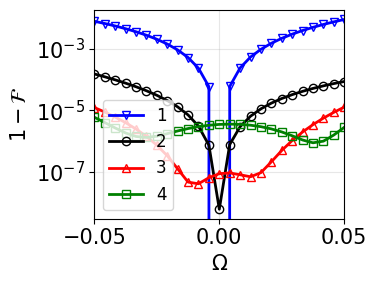

In [22]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
ax.plot(Eps, inf_const_standart_metrics_params, label='1', color='blue', markersize=6,marker='v',mfc='none' )
ax.plot(Eps, inf_const_best_new_metrics_params, label='2', color='black',marker='o', mfc='none',markersize=6)
ax.plot(Eps, inf_const_first_new_metrics_params,  label='3', color='red',marker='^', mfc='none', markersize=6)
ax.plot(Eps, inf_const_final_new_metrics_params, label='4', color='green', markersize=6, marker='s', mfc='none',)
# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\Omega$", fontsize=15, fontweight='bold')
ax.set_ylabel(r"$1-\mathcal{F}$", fontsize=15, fontweight='bold')
ax.set_yscale('log')
ax.tick_params(axis='both', labelsize=15,)
ax.set_xlim(-0.05, 0.05)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('Robustness_const_plot.svg', format='svg')

# Display the plot
plt.show()

(<Figure size 400x300 with 1 Axes>,
 <Axes: xlabel='$t/ T$', ylabel='$T\\Delta $, $\\xi$ [rad], $T\\Omega $'>)

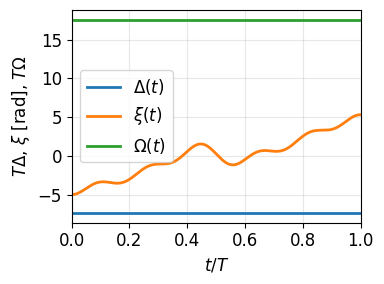

In [18]:
par = (1, [-7.290384292602539], [8.389602661132812, 0.1328800618648529, -0.5201250314712524, -1.20051908493042, 0.04195050150156021, 0.04394247382879257, -0.9032716751098633, 0.17269572615623474, 0.13556024432182312, 0.5273528099060059, -0.4541366696357727, -1.0407273769378662, 0.12601295113563538, 0.8883586525917053, -0.6206468939781189], [17.550800323486328])
pulse_ansatz = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)
plot_pulse(
    pulse_ansatz, 
    par)

***Optimization for finite blockade: constant Rabi frequency***

In [12]:
jax.config.update("jax_enable_x64", True)
pulse_ansatz_const = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.lin_sin_cos_crab,
    rabi_ansatz=ro.pulses.const,
)

# Тот же вентиль, что оптимизировали при идеальной блокаде, в нормировке duration=1
T_ideal = const_final_new_metrics_params[0]
params_ideal = (
    1.0,
    [const_final_new_metrics_params[1][0] * T_ideal],
    [const_final_new_metrics_params[2][0] * T_ideal, *const_final_new_metrics_params[2][1:]],
    [const_final_new_metrics_params[3][0] * T_ideal],
)

params_Vnn = {
    500: (1.0, [-7.35270881652832], [8.327069282531738, 0.10451477766036987, -0.5659801959991455, -1.214420199394226, 0.02697618305683136, 0.05053878575563431, -0.8865720629692078, 0.14298120141029358, 0.11660236120223999, 0.5230806469917297, -0.4591034948825836, -1.0639920234680176, 0.11116936802864075, 0.8640844821929932, -0.6128537654876709], [17.454347610473633]),
    400: (1.0, [-7.359248638153076], [8.32076644897461, 0.09853585809469223, -0.5787245631217957, -1.2233847379684448, 0.02165975794196129, 0.051469214260578156, -0.8823188543319702, 0.13746243715286255, 0.10754482448101044, 0.5188955664634705, -0.46075284481048584, -1.0675814151763916, 0.10419218987226486, 0.8545777797698975, -0.6111447811126709], [17.436279296875]),
    300: (1.0, [-7.363170146942139], [8.316801071166992, 0.09115435928106308, -0.5948308110237122, -1.2423580884933472, 0.004339245613664389, 0.05579052120447159, -0.8712098598480225, 0.1328430324792862, 0.08623947948217392, 0.5141709446907043, -0.4631825387477875, -1.0663965940475464, 0.09603452682495117, 0.836353600025177, -0.5974223017692566], [17.362398147583008]),
    200: (1.0, [-7.395792484283447], [8.284194946289062, 0.07436272501945496, -0.629087507724762, -1.2613575458526611, -0.010134457610547543, 0.06035637855529785, -0.8542963266372681, 0.12038649618625641, 0.06323481351137161, 0.5052236914634705, -0.4681903123855591, -1.0815509557724, 0.08202378451824188, 0.8074443340301514, -0.5844971537590027], [17.262659072875977]),
    100: (1.0, [-7.521523952484131], [8.158326148986816, -0.01600492000579834, -0.7031754851341248, -1.2683582305908203, 0.03499362990260124, -0.08726588636636734, -0.7944504618644714, 0.14256614446640015, 0.04927919805049896, 0.28525006771087646, -0.5115857124328613, -0.9183614253997803, 0.14508430659770966, 0.7026087045669556, -0.7159660458564758], [17.291011810302734]),
}

Vnn_list = [500, 400, 300, 200, 100]
colors = ['blue', 'black', 'red', 'green', 'purple']
markers = ['^', 'o', 'v', 's', 'D']
labels = [r'$BT=500$', r'$BT=400$', r'$BT=300$', r'$BT=200$', r'$BT=100$']

def scale_params(params, eps):
    duration = params[0]
    detuning_p = params[1]
    phase_p = params[2]
    rabi_p_noisy = params[3] * (1 + eps)
    return (duration, detuning_p, phase_p, rabi_p_noisy)

def make_compute(Vnn):
    gate_V = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float(Vnn), decay=0.0)
    def compute_fidelity_single(eps, base_params):
        noisy_p = scale_params(base_params, eps)
        final_state = ro.simulation.evolve(gate_V, pulse_ansatz_const, noisy_p)
        return gate_V.process_fidelity(final_state)
    return jax.jit(jax.vmap(compute_fidelity_single, in_axes=(0, None)))

Eps = jnp.linspace(-0.05, 0.05, 31)
params_ideal_jax = tuple(jnp.array(x) for x in params_ideal)

inf_left = {}
inf_right = {}
for Vnn in Vnn_list:
    compute_fidelity_jit = make_compute(Vnn)
    params_opt_jax = tuple(jnp.array(x) for x in params_Vnn[Vnn])
    inf_left[Vnn] = 1 - np.array(compute_fidelity_jit(Eps, params_ideal_jax))
    inf_right[Vnn] = 1 - np.array(compute_fidelity_jit(Eps, params_opt_jax))


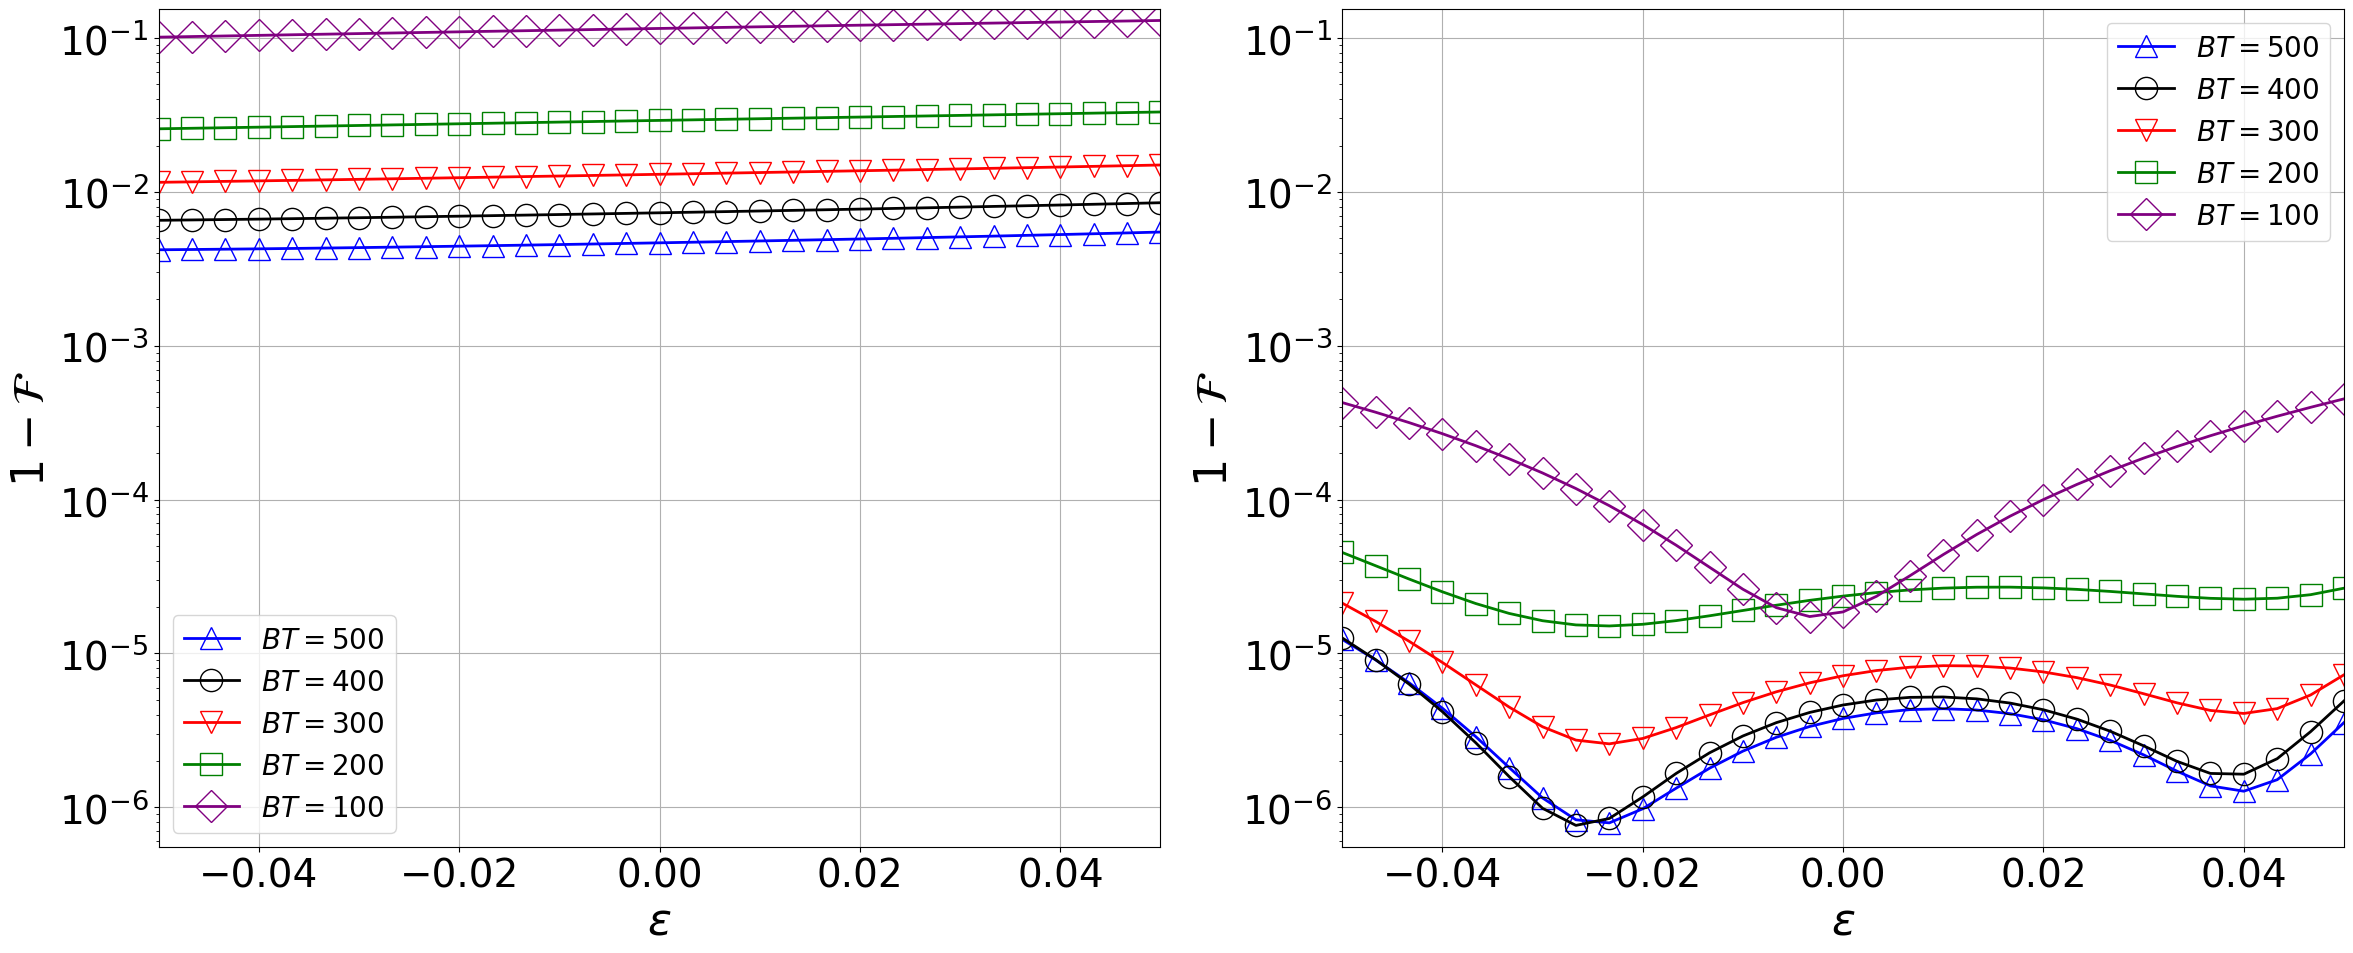

In [13]:
plt.rcParams.update({'font.size': 22})
plt.rcParams['lines.linewidth'] = 2

fig, axes = plt.subplots(1, 2, figsize=(24, 10))
for ax, data in ((axes[0], inf_left), (axes[1], inf_right)):
    for Vnn, color, marker, label in zip(Vnn_list, colors, markers, labels):
        y = np.maximum(np.asarray(data[Vnn], dtype=float), 1e-16)
        ax.plot(Eps, y, label=label, color=color, marker=marker, mfc='none', markersize=16)
    ax.set_xlabel(r"$\varepsilon$", fontsize=32, fontweight='bold')
    ax.set_ylabel(r"$1-\mathcal{F}$", fontsize=32, fontweight='bold')
    ax.set_yscale('log')
    ax.tick_params(axis='both', labelsize=28)
    ax.set_xlim(-0.05, 0.05)
    ax.grid()
    ax.legend(fontsize=20)
ymin = min(ax.get_ylim()[0] for ax in axes)
ymax = max(ax.get_ylim()[1] for ax in axes)
for ax in axes:
    ax.set_ylim(ymin, ymax)
fig.tight_layout()
plt.savefig('Const_blockade.svg', format='svg')
plt.show()

***Optimization for finite blockade: smooth pulse***

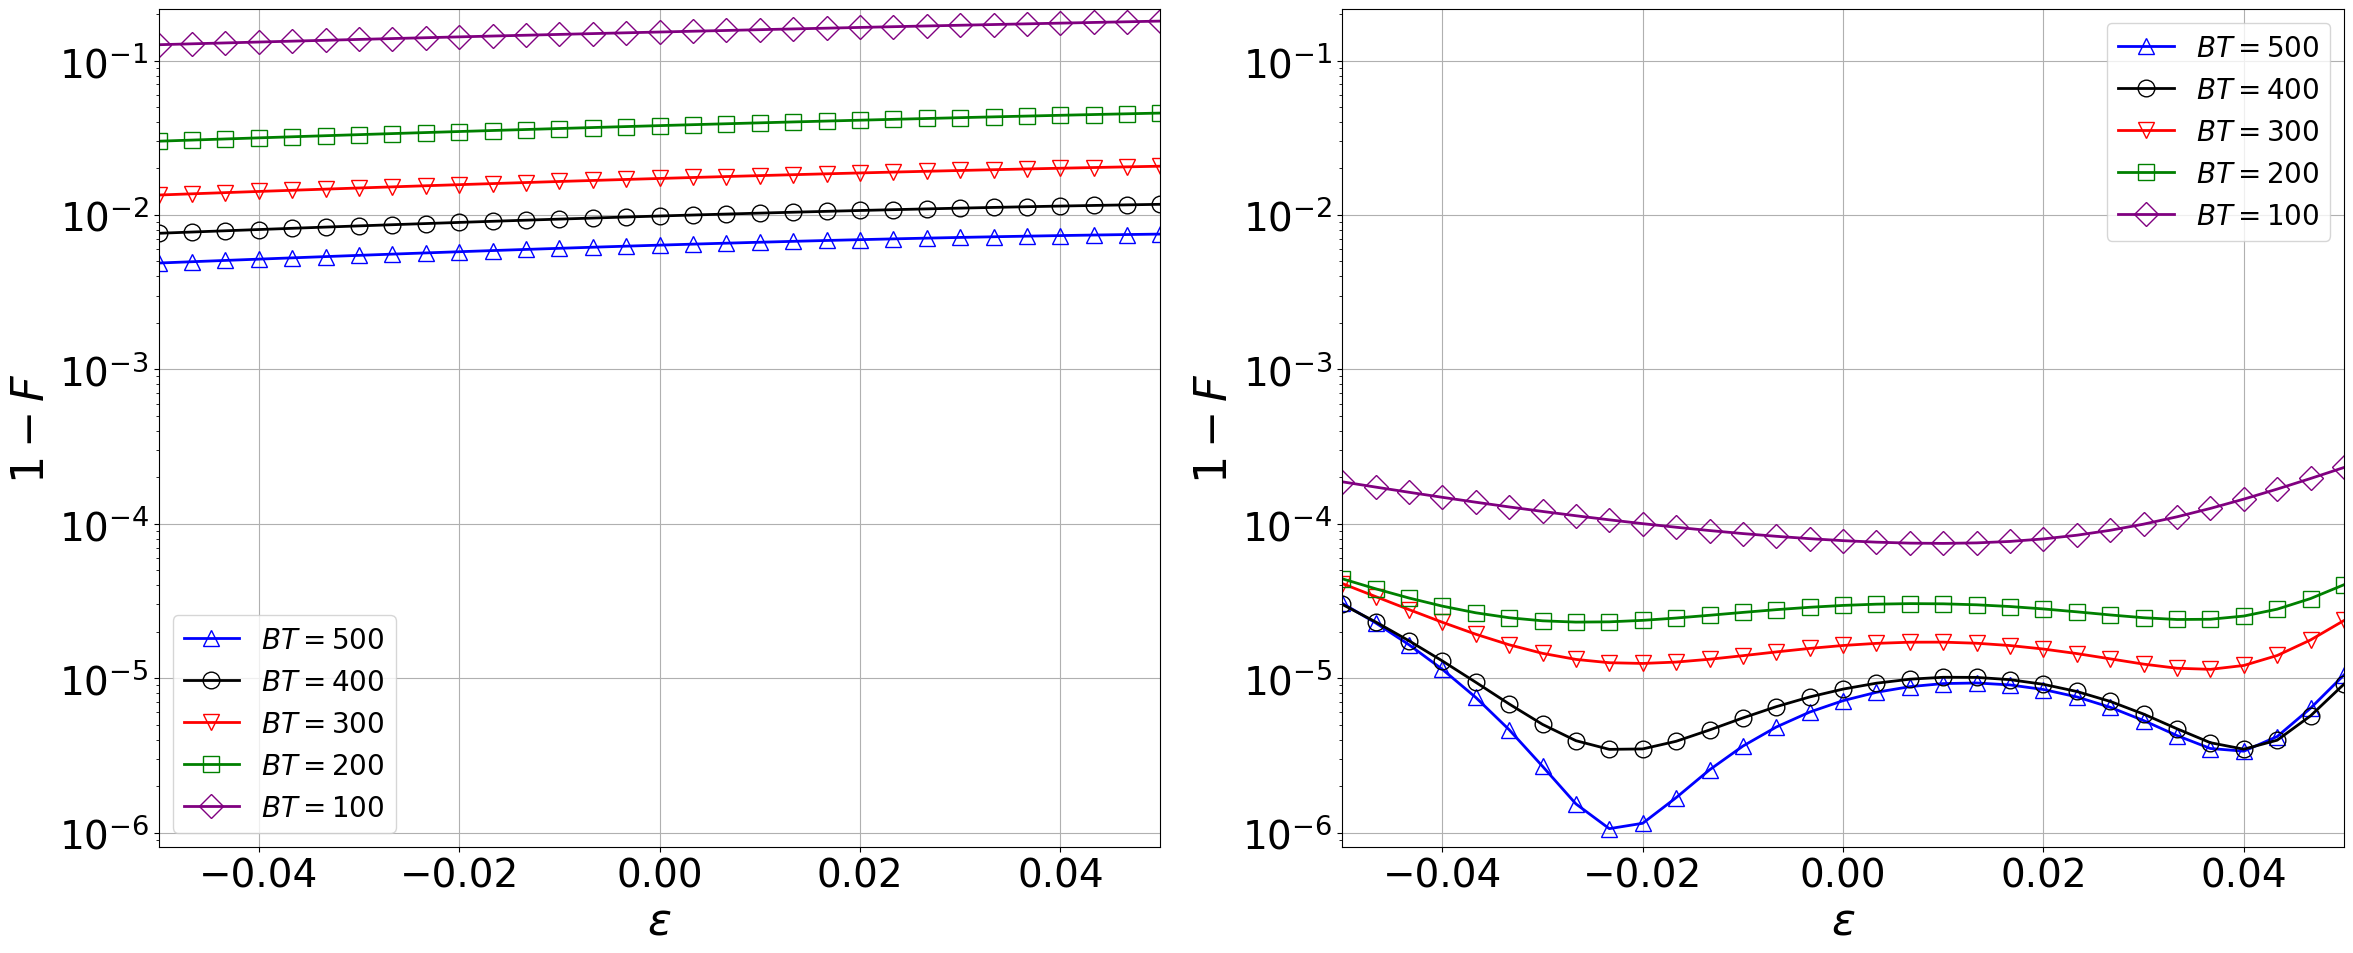

In [17]:
jax.config.update("jax_enable_x64", True)
pulse_ansatz_to = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.lin_sin_cos_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)

# Тот же TO-вентиль, что оптимизировали при идеальной блокаде, в нормировке duration=1
T_ideal = to_final_new_metrics_params[0]
params_ideal = (
    1.0,
    [to_final_new_metrics_params[1][0] * T_ideal],
    [to_final_new_metrics_params[2][0] * T_ideal, *to_final_new_metrics_params[2][1:]],
    [to_final_new_metrics_params[3][0] * T_ideal, to_final_new_metrics_params[3][1]],
)

params_Vnn = {
    500: (1.0, [9.121445655822754], [0.40243253111839294, 0.7589524984359741, -1.2777073383331299, 0.2604377269744873, 1.7878552675247192, 0.1500038355588913, -0.13677142560482025, 0.14020198583602905, -0.1863752007484436, -0.14489804208278656, 0.1924409419298172, -0.018599489703774452, -0.6102868318557739, 0.8758513927459717, 0.1380738765001297, -0.32945048809051514, -0.5795151591300964, -0.1269419640302658, 0.5316967964172363, -0.2201061248779297, -0.6058393120765686], [22.428089141845703, 0.24895963072776794]),
    400: (1.0, [9.121495246887207], [0.40246862173080444, 0.7580111026763916, -1.275713324546814, 0.2654135823249817, 1.796364426612854, 0.16515854001045227, -0.12615039944648743, 0.15352967381477356, -0.1769111454486847, -0.14604917168617249, 0.17576923966407776, -0.018783774226903915, -0.6089741587638855, 0.8796472549438477, 0.15374153852462769, -0.32277408242225647, -0.5794671177864075, -0.13396932184696198, 0.5369440913200378, -0.21844232082366943, -0.6095110774040222], [22.285844802856445, 0.24447888135910034]),
    300: (1.0, [9.115935325622559], [0.39692422747612, 0.7427433729171753, -1.279449701309204, 0.2767230272293091, 1.8114371299743652, 0.1470489799976349, -0.10822805762290955, 0.167483851313591, -0.17052917182445526, -0.15532198548316956, 0.17144492268562317, -0.012233825400471687, -0.5968111157417297, 0.8911120891571045, 0.16720227897167206, -0.3219967186450958, -0.5767694115638733, -0.14029094576835632, 0.539829432964325, -0.21630090475082397, -0.6181842684745789], [22.405344009399414, 0.24402165412902832]),
    200: (1.0, [9.100120544433594], [0.38113439083099365, 0.7023906111717224, -1.2518796920776367, 0.2917156219482422, 1.8560140132904053, 0.18675236403942108, -0.11221703141927719, 0.19709190726280212, -0.15800371766090393, -0.16092126071453094, 0.15488584339618683, -0.004893778823316097, -0.5779685974121094, 0.9234440922737122, 0.2076031118631363, -0.3122917711734772, -0.5794081687927246, -0.1489466279745102, 0.5616849660873413, -0.21158325672149658, -0.6360377073287964], [22.262176513671875, 0.23923401534557343]),
    100: (1.0, [8.88254165649414], [0.1635444015264511, 0.4348284602165222, -1.0307888984680176, 0.5093305706977844, 1.9447526931762695, -0.440787672996521, 0.40130650997161865, 0.09522383660078049, 0.12691177427768707, -0.0914710983633995, 0.3106828033924103, 0.15187273919582367, -0.3266034424304962, 1.0105663537979126, 0.4852057099342346, -0.15379774570465088, -0.5121270418167114, -0.1843278408050537, 0.6739806532859802, -0.09459612518548965, -0.554461658000946], [21.945266723632812, 0.23482303321361542]),
}

Vnn_list = [500, 400, 300, 200, 100]
colors = ['blue', 'black', 'red', 'green', 'purple']
markers = ['^', 'o', 'v', 's', 'D']
labels = [r'$BT=500$', r'$BT=400$', r'$BT=300$', r'$BT=200$', r'$BT=100$']

def scale_params(params, eps):
    duration = params[0]
    detuning_p = params[1]
    phase_p = params[2]
    rabi_p = params[3]
    rabi_p_noisy = rabi_p.at[0].set(rabi_p[0] * (1 + eps))
    return (duration, detuning_p, phase_p, rabi_p_noisy)

def make_compute(Vnn):
    gate_V = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float(Vnn), decay=0.0)
    def compute_fidelity_single(eps, base_params):
        noisy_p = scale_params(base_params, eps)
        final_state = ro.simulation.evolve(gate_V, pulse_ansatz_to, noisy_p)
        return gate_V.process_fidelity(final_state)
    return jax.jit(jax.vmap(compute_fidelity_single, in_axes=(0, None)))

Eps = jnp.linspace(-0.05, 0.05, 31)
params_ideal_jax = tuple(jnp.array(x) for x in params_ideal)

inf_left = {}
inf_right = {}
for Vnn in Vnn_list:
    compute_fidelity_jit = make_compute(Vnn)
    params_opt_jax = tuple(jnp.array(x) for x in params_Vnn[Vnn])
    inf_left[Vnn] = 1 - np.array(compute_fidelity_jit(Eps, params_ideal_jax))
    inf_right[Vnn] = 1 - np.array(compute_fidelity_jit(Eps, params_opt_jax))
    
plt.rcParams.update({'font.size': 22})
plt.rcParams['lines.linewidth'] = 2

fig, axes = plt.subplots(1, 2, figsize=(24, 10))
for ax, data in ((axes[0], inf_left), (axes[1], inf_right)):
    for Vnn, color, marker, label in zip(Vnn_list, colors, markers, labels):
        y = np.maximum(np.asarray(data[Vnn], dtype=float), 1e-16)
        ax.plot(Eps, y, label=label, color=color, marker=marker, mfc='none', markersize=12)
    ax.set_xlabel(r"$\varepsilon$", fontsize=32, fontweight='bold')
    ax.set_ylabel(r"$1-F$", fontsize=32, fontweight='bold')
    ax.set_yscale('log')
    ax.tick_params(axis='both', labelsize=28)
    ax.set_xlim(-0.05, 0.05)
    ax.grid()
    ax.legend(fontsize=20)
ymin = min(ax.get_ylim()[0] for ax in axes)
ymax = max(ax.get_ylim()[1] for ax in axes)
for ax in axes:
    ax.set_ylim(ymin, ymax)
fig.tight_layout()
plt.savefig('Smooth_blockade.svg', format='svg')
plt.show()
